**TUẦN 1: 2.1 + 2.2**

In [ ]:
# Cài Java 11 (khuyến nghị cho Spark 3.5.x)
!apt-get update -qq
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

print("Java version:")
!java -version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Java version:
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


In [ ]:
# Cách 2: Tải Spark binary thủ công
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz

import os
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"
!pip install findspark -q
import findspark
findspark.init()

In [ ]:
# Khởi tạo SparkSession
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Olist EDA") \
    .master("local[*]") \
    .getOrCreate()
print(f"\n✅ Spark Version: {spark.version}")
print(f"Spark UI: {spark.sparkContext.uiWebUrl}")


✅ Spark Version: 3.5.1
Spark UI: http://11b3c387ac12:4040


In [ ]:
!pip install -q streamlit
print("\nStreamlit installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 37.6 MB/s eta 0:00:00

Streamlit installed successfully.


In [ ]:
!python --version

Python 3.12.13


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/datasetCuoiKy"

In [ ]:
customers_df = spark.read.csv("/content/drive/MyDrive/datasetCuoiKy/olist_customers_dataset.csv", header=True, inferSchema=True)
geolocation_df = spark.read.csv("/content/drive/MyDrive/datasetCuoiKy/olist_geolocation_dataset.csv", header=True, inferSchema=True)
order_items_df = spark.read.csv("/content/drive/MyDrive/datasetCuoiKy/olist_order_items_dataset.csv", header=True, inferSchema=True)
payments_df = spark.read.csv("/content/drive/MyDrive/datasetCuoiKy/olist_order_payments_dataset.csv", header=True, inferSchema=True)
reviews_df = spark.read.csv("/content/drive/MyDrive/datasetCuoiKy/olist_order_reviews_dataset.csv", header=True, inferSchema=True)
orders_df = spark.read.csv("/content/drive/MyDrive/datasetCuoiKy/olist_orders_dataset.csv", header=True, inferSchema=True)
products_df = spark.read.csv("/content/drive/MyDrive/datasetCuoiKy/olist_products_dataset.csv", header=True, inferSchema=True)
sellers_df = spark.read.csv("/content/drive/MyDrive/datasetCuoiKy/olist_sellers_dataset.csv", header=True, inferSchema=True)
category_df = spark.read.csv("/content/drive/MyDrive/datasetCuoiKy/product_category_name_translation.csv", header=True, inferSchema=True)

In [ ]:
from pyspark.sql.functions import col, sum

def explore_full(df, name):
    print("\n==============================")
    print("DATASET:", name)
    print("==============================")

    # 1. Số dòng
    total_rows = df.count()
    print("Số dòng:", total_rows)

    # 2. Schema
    print("\nSchema:")
    df.printSchema()

    # 3. Dữ liệu mẫu
    print("\n5 dòng đầu:")
    df.show(5, truncate=False)

    # 4. Thống kê mô tả
    print("\nThống kê:")
    df.describe().show()

    # 5. Kiểm tra null
    print("\nSố lượng NULL theo cột:")
    null_df = df.select([
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])
    null_df.show()

    # 6. Kiểm tra duplicate
    unique_rows = df.dropDuplicates().count()
    print("\nDuplicate:")
    print("Tổng:", total_rows)
    print("Unique:", unique_rows)
    print("Số dòng trùng:", total_rows - unique_rows)

In [ ]:
explore_full(customers_df, "customers")


DATASET: customers
Số dòng: 99441

Schema:
root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city        |customer_state|
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|06b8999e2fba1a1fbc88172c00ba8bc7|861eff4711a542e4b93843c6dd7febb0|14409                   |franca               |SP            |
|18955e83d337fd6b2def6b18a428ac77|290c77bc529b7ac935b93aa66c333dc3|9790                    |sao bernardo do campo|SP            |
|4e7b3e00288586ebd08712fdd0374a03|060e732b5b29

In [ ]:
explore_full(geolocation_df, "geolocation")


DATASET: geolocation
Số dòng: 1000163

Schema:
root
 |-- geolocation_zip_code_prefix: integer (nullable = true)
 |-- geolocation_lat: double (nullable = true)
 |-- geolocation_lng: double (nullable = true)
 |-- geolocation_city: string (nullable = true)
 |-- geolocation_state: string (nullable = true)


5 dòng đầu:
+---------------------------+-------------------+------------------+----------------+-----------------+
|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng   |geolocation_city|geolocation_state|
+---------------------------+-------------------+------------------+----------------+-----------------+
|1037                       |-23.54562128115268 |-46.63929204800168|sao paulo       |SP               |
|1046                       |-23.546081127035535|-46.64482029837157|sao paulo       |SP               |
|1046                       |-23.54612896641469 |-46.64295148361138|sao paulo       |SP               |
|1041                       |-23.5443921648681  |-46.63949

In [ ]:
explore_full(order_items_df, "order_items")


DATASET: order_items
Số dòng: 112650

Schema:
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price|freight_value|
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|00010242fe8c5a6d1ba2dd792cb16214|1            |4244733e06e7ecb4970a6e2683c13e61|48436dade18ac8b2bce089ec2a041202|2017-09-19 09:45:35|58.9 |13.29        |
|00018f77

In [ ]:
explore_full(payments_df, "payments")


DATASET: payments
Số dòng: 103886

Schema:
root
 |-- order_id: string (nullable = true)
 |-- payment_sequential: integer (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: integer (nullable = true)
 |-- payment_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+------------------+------------+--------------------+-------------+
|order_id                        |payment_sequential|payment_type|payment_installments|payment_value|
+--------------------------------+------------------+------------+--------------------+-------------+
|b81ef226f3fe1789b1e8b2acac839d17|1                 |credit_card |8                   |99.33        |
|a9810da82917af2d9aefd1278f1dcfa0|1                 |credit_card |1                   |24.39        |
|25e8ea4e93396b6fa0d3dd708e76c1bd|1                 |credit_card |1                   |65.71        |
|ba78997921bbcdc1373bb41e913ab953|1                 |credit_card |8                   |107.7

In [ ]:
explore_full(reviews_df, "reviews")


DATASET: reviews
Số dòng: 104162

Schema:
root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: string (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: string (nullable = true)
 |-- review_answer_timestamp: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+--------------------+----------------------------------------------------------------------------------------------------+--------------------+-----------------------+
|review_id                       |order_id                        |review_score|review_comment_title|review_comment_message                                                                              |review_creation_date|review_answer_timestamp|
+--------------------------------+--------------------------------+------------+--------------------+---

In [ ]:
explore_full(orders_df, "orders")


DATASET: orders
Số dòng: 99441

Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+-

In [ ]:
explore_full(products_df, "products")


DATASET: products
Số dòng: 32951

Schema:
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)


5 dòng đầu:
+--------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|product_id                      |product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------------------+---------------------+-------------------+---------------------

In [ ]:
explore_full(sellers_df, "sellers")


DATASET: sellers
Số dòng: 3095

Schema:
root
 |-- seller_id: string (nullable = true)
 |-- seller_zip_code_prefix: integer (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+----------------------+-----------------+------------+
|seller_id                       |seller_zip_code_prefix|seller_city      |seller_state|
+--------------------------------+----------------------+-----------------+------------+
|3442f8959a84dea7ee197c632cb2df15|13023                 |campinas         |SP          |
|d1b65fc7debc3361ea86b5f14c68d2e2|13844                 |mogi guacu       |SP          |
|ce3ad9de960102d0677a81f5d0bb7b2d|20031                 |rio de janeiro   |RJ          |
|c0f3eea2e14555b6faeea3dd58c1b1c3|4195                  |sao paulo        |SP          |
|51a04a8a6bdcb23deccc82b0b80742cf|12914                 |braganca paulista|SP          |
+--------------------------------+-----------

In [ ]:
explore_full(category_df, "category_translation")


DATASET: category_translation
Số dòng: 71

Schema:
root
 |-- product_category_name: string (nullable = true)
 |-- product_category_name_english: string (nullable = true)


5 dòng đầu:
+----------------------+-----------------------------+
|product_category_name |product_category_name_english|
+----------------------+-----------------------------+
|beleza_saude          |health_beauty                |
|informatica_acessorios|computers_accessories        |
|automotivo            |auto                         |
|cama_mesa_banho       |bed_bath_table               |
|moveis_decoracao      |furniture_decor              |
+----------------------+-----------------------------+
only showing top 5 rows


Thống kê:
+-------+---------------------+-----------------------------+
|summary|product_category_name|product_category_name_english|
+-------+---------------------+-----------------------------+
|  count|                   71|                           71|
|   mean|                 NULL|     

TUẦN 1: 2.4.Tiền xử lý dữ liệu

In [ ]:
from pyspark.sql import SparkSession

# Khởi tạo Spark session
spark = SparkSession.builder \
    .appName("Olist_Load_Parquet") \
    .getOrCreate()

# Đường dẫn file
file_path = "/content/drive/MyDrive/datasetCuoiKy/olist_master_processed.parquet"

# Đọc file Parquet
df_master = spark.read.parquet(file_path)

# CLASSIFiCATION

In [ ]:
# ==============================
# 1. PREPROCESS (FIX NHẸ)
# ==============================
from pyspark.sql.functions import when, col

df_ml = df_master.filter(col("review_score").isNotNull())

df_ml = df_ml.withColumn(
    "label",
    when(col("review_score") <= 3, 0).otherwise(1)
)

# FIX leakage: xử lý trước khi split
df_ml = df_ml.withColumn(
    "delivery_delay_days",
    when(col("delivery_delay_days") < 0, 0)
    .otherwise(col("delivery_delay_days"))
)

df_ml = df_ml.fillna({
    "delivery_delay_days": 0,
    "total_freight_value": 0,
    "total_price": 0,
    "num_items": 0,
    "product_weight_g": 0,
    "is_late_delivery": 0,
    "product_photos_qty": 0,
    "product_category_name_english": "unknown",
    "payment_type": "unknown",
    "customer_state": "unknown",
    "seller_state": "unknown"
})

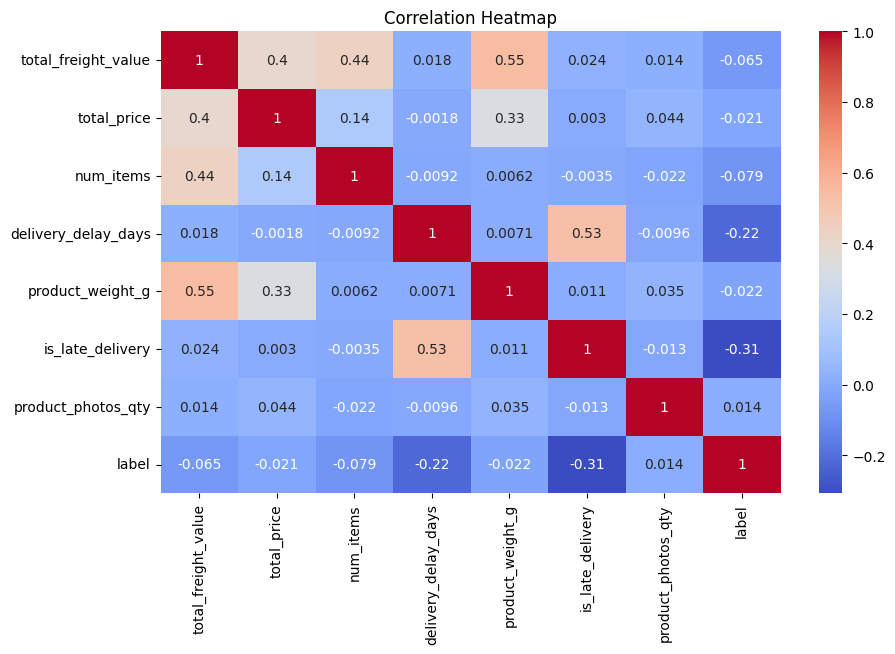

In [ ]:
# ==============================
# HEATMAP - CHỌN FEATURE
# ==============================

# Lấy các cột số + label
numeric_cols = [
    "total_freight_value",
    "total_price",
    "num_items",
    "delivery_delay_days",
    "product_weight_g",
    "is_late_delivery",
    "product_photos_qty",
    "label"
]

# Sample để tránh nặng
pdf = df_ml.select(numeric_cols).sample(fraction=0.1, seed=42).toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

# Correlation
corr = pdf.corr()

# Vẽ heatmap tổng
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from pyspark.sql.functions import avg, count

def check_categorical(df, col_name):
    print(f"\n=== {col_name} ===")

    df.groupBy(col_name).agg(
        count("*").alias("count"),
        avg("label").alias("avg_label")
    ).orderBy("avg_label").show(20, False)

# chạy thử
check_categorical(df_ml, "payment_type")
check_categorical(df_ml, "product_category_name_english")
check_categorical(df_ml, "customer_state")
check_categorical(df_ml, "seller_state")


=== payment_type ===
+------------+-----+------------------+
|payment_type|count|avg_label         |
+------------+-----+------------------+
|not_defined |3    |0.0               |
|unknown     |1    |0.0               |
|voucher     |2739 |0.73311427528295  |
|boleto      |19784|0.7643550343712091|
|credit_card |75387|0.7657421040762996|
|debit_card  |1527 |0.7897838899803536|
+------------+-----+------------------+


=== product_category_name_english ===
+---------------------------------+-----+------------------+
|product_category_name_english    |count|avg_label         |
+---------------------------------+-----+------------------+
|security_and_services            |2    |0.5               |
|unknown                          |2212 |0.5230560578661845|
|fashio_female_clothing           |39   |0.6153846153846154|
|office_furniture                 |1265 |0.6260869565217392|
|diapers_and_hygiene              |27   |0.6666666666666666|
|fashion_male_clothing            |112  |0.6696428

In [ ]:
# ==============================
# 2. FEATURE PIPELINE (KHÔNG LẶP)
# ==============================
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, ChiSqSelector

categorical_cols = ["payment_type", "product_category_name_english", "customer_state", "seller_state"]

indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_vec")
    for c in categorical_cols
]

numeric_cols = [
    "total_freight_value",
    "total_price",
    "num_items",
    "delivery_delay_days",
    "product_weight_g",
    "is_late_delivery",
]

feature_cols = numeric_cols + [c + "_vec" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

selector = ChiSqSelector(
    numTopFeatures=20,
    featuresCol="features",
    outputCol="selected_features",
    labelCol="label"
)

# PIPELINE CHUNG
from pyspark.ml import Pipeline
base_pipeline = Pipeline(stages=indexers + encoders + [assembler, selector])


In [ ]:
# ==============================
# 3. SPLIT DATA
# ==============================
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# ==============================
# 4. CROSS VALIDATION SETUP
# ==============================
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import time

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

In [ ]:
# ==============================
# 5. TRAIN FUNCTION (TRÁNH LẶP CODE)
# ==============================
def train_with_cv(model, paramGrid, name):
    pipeline = Pipeline(stages=base_pipeline.getStages() + [model])

    cv = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=paramGrid,
        evaluator=evaluator,
        numFolds=5,
        parallelism=2
    )

    start = time.time()
    cv_model = cv.fit(train_df)
    train_time = time.time() - start

    pred = cv_model.transform(test_df)

    return cv_model, pred, train_time, name

In [ ]:
# ==============================
# 6. TRAIN ALL MODELS
# ==============================

from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, NaiveBayes, LinearSVC, GBTClassifier

# Logistic Regression
lr = LogisticRegression(featuresCol="selected_features", labelCol="label")
param_lr = (ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5])
    .addGrid(lr.maxIter, [50, 100])
    .build())

model_lr, pred_lr, time_lr, name_lr = train_with_cv(lr, param_lr, "Logistic Regression")


In [ ]:
# ================================================
# VI.1.2 - LOGISTIC REGRESSION - METRICS
# ================================================

from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

print("="*70)
print("VI.1.2 LOGISTIC REGRESSION - MODEL EVALUATION")
print("="*70)

# Dự đoán trên tập test
pred_lr = model_lr.transform(test_df)

# Chuyển kết quả về Pandas để tính metrics dễ dàng
y_true = pred_lr.select("label").toPandas()["label"]
y_pred = pred_lr.select("prediction").toPandas()["prediction"]

# ============================
# 1. Classification Report
# ============================
print("\n1. CLASSIFICATION REPORT - LOGISTIC REGRESSION")
print("-" * 60)
print(classification_report(y_true, y_pred,
                            target_names=["Class 0 (Negative)", "Class 1 (Positive)"],
                            digits=4))

# ============================
# 2. Manual Metrics (Macro + AUC)
# ============================
print("\n2. METRICS SUMMARY")
print("-" * 50)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Tính AUC (Area Under ROC Curve)
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = auc_evaluator.evaluate(pred_lr)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall    (Macro)  : {recall:.4f}")
print(f"F1-score  (Macro)  : {f1:.4f}")
print(f"AUC       (ROC)    : {auc:.4f}")


VI.1.2 LOGISTIC REGRESSION - MODEL EVALUATION

1. CLASSIFICATION REPORT - LOGISTIC REGRESSION
------------------------------------------------------------
                    precision    recall  f1-score   support

Class 0 (Negative)     0.7058    0.2542    0.3738      4560
Class 1 (Positive)     0.8120    0.9682    0.8832     15169

          accuracy                         0.8031     19729
         macro avg     0.7589    0.6112    0.6285     19729
      weighted avg     0.7874    0.8031    0.7655     19729


2. METRICS SUMMARY
--------------------------------------------------
Accuracy           : 0.8031
Precision (Macro)  : 0.7589
Recall    (Macro)  : 0.6112
F1-score  (Macro)  : 0.6285
AUC       (ROC)    : 0.6739


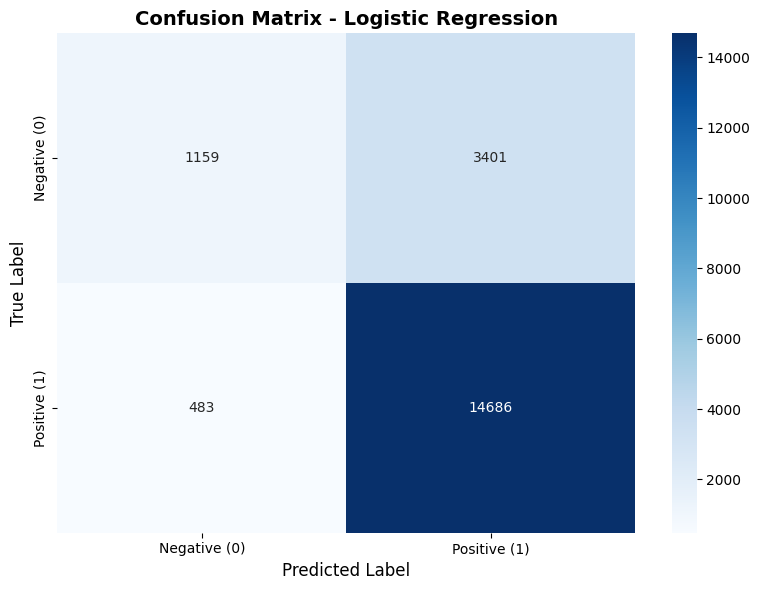

In [ ]:
# ================================================
# VI.1.2 - LOGISTIC REGRESSION - CONFUSION MATRIX
# ================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tính Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Vẽ biểu đồ
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            cbar=True)

plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()


In [ ]:
# Random Forest
rf = RandomForestClassifier(featuresCol="selected_features", labelCol="label")
param_rf = (ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [8, 12])
    .addGrid(rf.featureSubsetStrategy, ["sqrt", "log2"])
    .build())

model_rf, pred_rf, time_rf, name_rf = train_with_cv(rf, param_rf, "Random Forest")



In [ ]:
# ================================================
# VI.1.3 - RANDOM FOREST CLASSIFIER - METRICS & FEATURE IMPORTANCE
# ================================================

from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("="*75)
print("VI.1.3 RANDOM FOREST CLASSIFIER - MODEL EVALUATION")
print("="*75)

# Dự đoán trên tập test
pred_rf = model_rf.transform(test_df)   # <-- Đảm bảo dùng model_rf (Random Forest)

# Chuyển về Pandas
y_true = pred_rf.select("label").toPandas()["label"]
y_pred = pred_rf.select("prediction").toPandas()["prediction"]

# ============================
# 1. Classification Report
# ============================
print("\n1. CLASSIFICATION REPORT - RANDOM FOREST")
print("-" * 65)
print(classification_report(y_true, y_pred,
                            target_names=["Class 0 (Negative)", "Class 1 (Positive)"],
                            digits=4))

# ============================
# 2. Metrics Summary (Macro + AUC)
# ============================
print("\n2. METRICS SUMMARY")
print("-" * 50)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Tính AUC
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = auc_evaluator.evaluate(pred_rf)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall    (Macro)  : {recall:.4f}")
print(f"F1-score  (Macro)  : {f1:.4f}")
print(f"AUC       (ROC)    : {auc:.4f}")



VI.1.3 RANDOM FOREST CLASSIFIER - MODEL EVALUATION

1. CLASSIFICATION REPORT - RANDOM FOREST
-----------------------------------------------------------------
                    precision    recall  f1-score   support

Class 0 (Negative)     0.8043    0.2235    0.3498      4560
Class 1 (Positive)     0.8082    0.9837    0.8873     15169

          accuracy                         0.8079     19729
         macro avg     0.8062    0.6036    0.6185     19729
      weighted avg     0.8073    0.8079    0.7631     19729


2. METRICS SUMMARY
--------------------------------------------------
Accuracy           : 0.8079
Precision (Macro)  : 0.8062
Recall    (Macro)  : 0.6036
F1-score  (Macro)  : 0.6185
AUC       (ROC)    : 0.6788



3. TOP 15 FEATURE IMPORTANCE - RANDOM FOREST
------------------------------------------------------------
                                              Feature  Importance
3                                 delivery_delay_days    0.431851
5                                    is_late_delivery    0.204638
2                                           num_items    0.073141
0                                 total_freight_value    0.053816
19                           seller_state_vec_unknown    0.049828
1                                         total_price    0.046017
4                                    product_weight_g    0.041025
6                                  product_photos_qty    0.031623
11          product_category_name_english_vec_unknown    0.018477
15                              customer_state_vec_RJ    0.007722
7    product_category_name_english_vec_bed_bath_table    0.006594
14                              customer_state_vec_SP    0.006265
12  product_category_name_english_v

/tmp/ipykernel_6775/854656353.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')


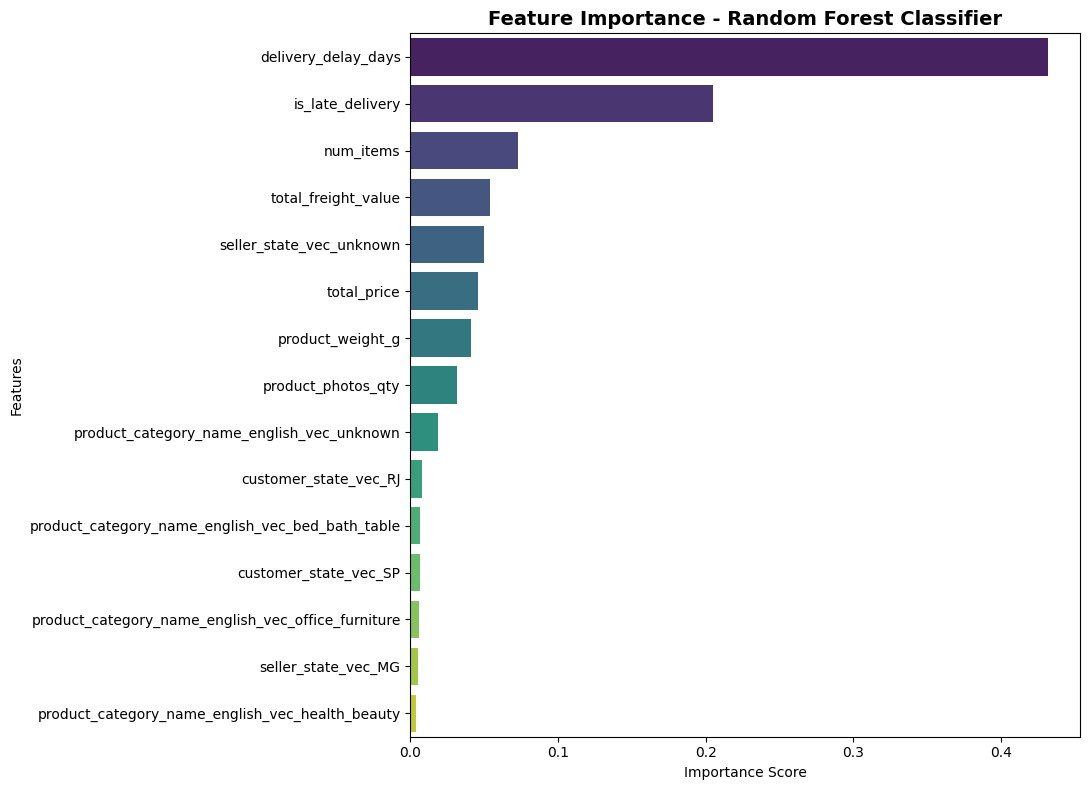

In [ ]:
# ============================
# 3. FEATURE IMPORTANCE - PHIÊN BẢN ỔN ĐỊNH
# ============================
print("\n3. TOP 15 FEATURE IMPORTANCE - RANDOM FOREST")
print("-" * 60)

# Lấy Random Forest model
rf_model = model_rf.bestModel.stages[-1]

# Lấy vector feature importances
importances = rf_model.featureImportances.toArray()

# Lấy tên các feature từ metadata của VectorAssembler
# Tìm stage VectorAssembler trong pipeline
assembler_stage = None
for stage in reversed(model_rf.bestModel.stages):   # tìm từ cuối lên
    if stage.__class__.__name__ == "VectorAssembler":
        assembler_stage = stage
        break

if assembler_stage is not None:
    # Lấy metadata từ output column
    output_col = assembler_stage.getOutputCol()
    metadata = pred_rf.schema[output_col].metadata["ml_attr"]["attrs"]

    feature_list = []
    for key in ['numeric', 'binary']:
        if key in metadata:
            feature_list.extend([attr['name'] for attr in metadata[key]])

    # Vì ChiSqSelector đã chọn một số feature, ta lấy đúng index được chọn
    selector_stage = model_rf.bestModel.stages[-2]  # ChiSqSelector
    selected_indices = selector_stage.selectedFeatures

    feature_names = [feature_list[i] for i in selected_indices]
else:
    feature_names = [f"feature_{i}" for i in range(len(importances))]

# Tạo DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp_df.head(15))

# ============================
# 4. Vẽ Feature Importance Plot
# ============================
plt.figure(figsize=(11, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')
plt.title('Feature Importance - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()

In [ ]:
# Naive Bayes
nb = NaiveBayes(featuresCol="selected_features", labelCol="label")
param_nb = (ParamGridBuilder()
    .addGrid(nb.smoothing, [0.5, 1.0, 1.5])
    .build())

model_nb, pred_nb, time_nb, name_nb = train_with_cv(nb, param_nb, "Naive Bayes")


In [ ]:
# Linear SVC
svc = LinearSVC(featuresCol="selected_features", labelCol="label")
param_svc = (ParamGridBuilder()
    .addGrid(svc.regParam, [0.01, 0.1, 1.0])
    .addGrid(svc.maxIter, [50, 100])
    .build())

model_svc, pred_svc, time_svc, name_svc = train_with_cv(svc, param_svc, "LinearSVC")



In [ ]:
# GBT
gbt = GBTClassifier(featuresCol="selected_features", labelCol="label")
param_gbt = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.maxIter, [20, 30])
    .addGrid(gbt.stepSize, [0.05, 0.1])
    .build())

model_gbt, pred_gbt, time_gbt, name_gbt = train_with_cv(gbt, param_gbt, "GBTClassifier")


In [ ]:
print("\n===== BEST PARAMS =====")

def print_best_params(cv_model, model_name):
    print(f"\n🔹 {model_name}")

    best_model = cv_model.bestModel.stages[-1]
    # stages[-1] = model cuối (lr, rf, nb, ...)

    param_map = best_model.extractParamMap()

    for param, value in param_map.items():
        print(f"{param.name}: {value}")


# In từng model
print_best_params(model_lr, "Logistic Regression")
print_best_params(model_rf, "Random Forest")
print_best_params(model_nb, "Naive Bayes")
print_best_params(model_svc, "LinearSVC")
print_best_params(model_gbt, "GBTClassifier")


===== BEST PARAMS =====

🔹 Logistic Regression
aggregationDepth: 2
elasticNetParam: 0.0
family: auto
featuresCol: selected_features
fitIntercept: True
labelCol: label
maxBlockSizeInMB: 0.0
maxIter: 50
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
regParam: 0.01
standardization: True
threshold: 0.5
tol: 1e-06

🔹 Random Forest
bootstrap: True
cacheNodeIds: False
checkpointInterval: 10
featureSubsetStrategy: sqrt
featuresCol: selected_features
impurity: gini
labelCol: label
leafCol: 
maxBins: 32
maxDepth: 12
maxMemoryInMB: 256
minInfoGain: 0.0
minInstancesPerNode: 1
minWeightFractionPerNode: 0.0
numTrees: 100
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
seed: -114067063113186888
subsamplingRate: 1.0

🔹 Naive Bayes
featuresCol: selected_features
labelCol: label
modelType: multinomial
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
smoothing: 0.5

🔹 LinearSVC
aggregationDe

In [ ]:
def evaluate_full(pred, name, train_time):
    # 1. Accuracy
    acc = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    ).evaluate(pred)

    # 2. RDD cho MulticlassMetrics (giữ float)
    rdd = pred.select("prediction", "label") \
              .rdd.map(lambda x: (float(x[0]), float(x[1])))
    metrics = MulticlassMetrics(rdd)

    # 3. Lấy tất cả label
    labels = pred.select("label").distinct().rdd.map(lambda x: float(x[0])).collect()

    # 4. Macro metrics
    macro_precision = np.mean([metrics.precision(l) for l in labels])
    macro_recall = np.mean([metrics.recall(l) for l in labels])
    macro_f1 = np.mean([metrics.fMeasure(l) for l in labels])

    # 5. AUC
    auc = evaluator.evaluate(pred)

    # 6. Print
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Macro Precision:", macro_precision)
    print("Macro Recall:", macro_recall)
    print("Macro F1:", macro_f1)
    print("AUC-ROC:", auc)
    print("Train time:", train_time)

    return [name, acc, macro_precision, macro_recall, macro_f1, auc, train_time]
results = []

results.append(evaluate_full(pred_lr,   name_lr,   time_lr))
results.append(evaluate_full(pred_rf,   name_rf,   time_rf))
results.append(evaluate_full(pred_nb,   name_nb,   time_nb))
results.append(evaluate_full(pred_svc,  name_svc,  time_svc))
results.append(evaluate_full(pred_gbt,  name_gbt,  time_gbt))

# Bảng tóm tắt
import pandas as pd
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision_Macro", "Recall_Macro",
    "F1_Macro", "AUC", "Train_Time(s)"
])

print("\n" + "="*90)
print("SUMMARY - MODEL PERFORMANCE (MACRO AVERAGE)")
print("="*90)
print(results_df.round(4))


Logistic Regression
Accuracy: 0.8031324446246642
Macro Precision: 0.7589054614699948
Macro Recall: 0.6111627057375788
Macro F1: 0.6284797240400697
AUC-ROC: 0.6739113661518816
Train time: 590.4717900753021

Random Forest
Accuracy: 0.8079476912159764
Macro Precision: 0.8062313323119303
Macro Recall: 0.6035578895901499
Macro F1: 0.6185436235641055
AUC-ROC: 0.6787667498811635
Train time: 2401.0753543376923

Naive Bayes
Accuracy: 0.8011556591819149
Macro Precision: 0.7540288168143057
Macro Recall: 0.6071931385917493
Macro F1: 0.6232153699962831
AUC-ROC: 0.5323799808704964
Train time: 144.88361859321594

LinearSVC
Accuracy: 0.7999391758325308
Macro Precision: 0.7448389359393759
Macro Recall: 0.609699599425421
Macro F1: 0.6263144598733256
AUC-ROC: 0.5858425409971629
Train time: 1349.1733078956604

GBTClassifier
Accuracy: 0.8086573065031173
Macro Precision: 0.8122115100641538
Macro Recall: 0.6035592340912271
Macro F1: 0.6185446058984465
AUC-ROC: 0.6805920618921555
Train time: 1826.04289317131

In [ ]:
# ==============================
# 8. BEST MODEL
# ==============================
best_result = results[0]

for r in results:
    if r[4] > best_result[4]:
        best_result = r

best_model_name = best_result[0]

print("\nBest model:", best_model_name)

model_dict = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "Naive Bayes": model_nb,
    "LinearSVC": model_svc,
    "GBTClassifier": model_gbt
}

best_model = model_dict[best_model_name]



Best model: Logistic Regression


In [ ]:
# SAVE
save_path = "/content/drive/MyDrive/modelss/best_model.2"
best_model.write().overwrite().save(save_path)
print("✅ Saved!")

✅ Saved!


In [ ]:
def check_overfitting(cv_model, train_df, test_df, model_name):
    print(f"\n===== {model_name} =====")

    # Predict train
    pred_train = cv_model.transform(train_df)

    # Predict test
    pred_test = cv_model.transform(test_df)

    # Evaluate
    train_metrics = evaluate_full(pred_train, "train", 0)[1:6]
    test_metrics = evaluate_full(pred_test, "test", 0)[1:6]


    metric_names = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

    print("\n--- TRAIN ---")
    for name, val in zip(metric_names, train_metrics):
        print(f"{name}: {val:.4f}")

    print("\n--- TEST ---")
    for name, val in zip(metric_names, test_metrics):
        print(f"{name}: {val:.4f}")

    print("\n--- GAP (Train - Test) ---")
    for name, tr, te in zip(metric_names, train_metrics, test_metrics):
        print(f"{name}: {(tr - te):.4f}")

In [ ]:
check_overfitting(model_lr, train_df, test_df, "Logistic Regression")
check_overfitting(model_rf, train_df, test_df, "Random Forest")
check_overfitting(model_nb, train_df, test_df, "Naive Bayes")
check_overfitting(model_svc, train_df, test_df, "LinearSVC")
check_overfitting(model_gbt, train_df, test_df, "GBTClassifier")



===== Logistic Regression =====


/content/spark-3.5.1-bin-hadoop3/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



train
Accuracy: 0.7979852468887997
Macro Precision: 0.7543247221605218
Macro Recall: 0.608967164918486
Macro F1: 0.624670991103378
AUC-ROC: 0.6710237852253244
Train time: 0

test
Accuracy: 0.8031324446246642
Macro Precision: 0.7589054614699948
Macro Recall: 0.6111627057375788
Macro F1: 0.6284797240400697
AUC-ROC: 0.6739163971881712
Train time: 0

--- TRAIN ---
Accuracy: 0.7980
Precision: 0.7543
Recall: 0.6090
F1: 0.6247
AUC: 0.6710

--- TEST ---
Accuracy: 0.8031
Precision: 0.7589
Recall: 0.6112
F1: 0.6285
AUC: 0.6739

--- GAP (Train - Test) ---
Accuracy: -0.0051
Precision: -0.0046
Recall: -0.0022
F1: -0.0038
AUC: -0.0029

===== Random Forest =====

train
Accuracy: 0.8095644319550381
Macro Precision: 0.8287251790746752
Macro Recall: 0.6108728798381007
Macro F1: 0.6277548484202566
AUC-ROC: 0.7013373249825693
Train time: 0

test
Accuracy: 0.8079476912159764
Macro Precision: 0.8062313323119303
Macro Recall: 0.6035578895901499
Macro F1: 0.6185436235641055
AUC-ROC: 0.678775763821182
Train t

          Pred 0  Pred 1
Actual 0    1159    3401
Actual 1     483   14686


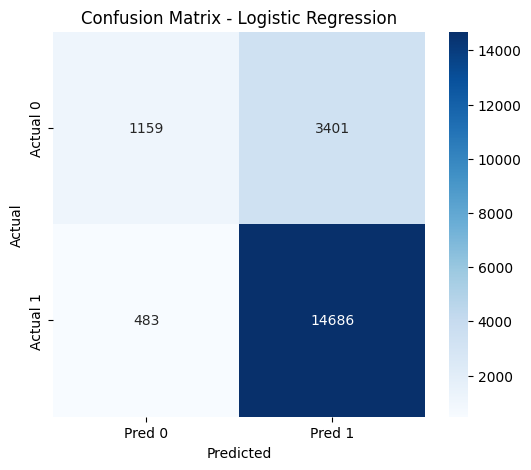

In [ ]:
# ============================
# CONFUSION MATRIX (BEST MODEL)
# ============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔥 QUAN TRỌNG: tạo prediction từ best model
pred_best = best_model.transform(test_df)

# Convert Spark -> Pandas
pdf = pred_best.select("label", "prediction").toPandas()

# Ép kiểu
pdf["label"] = pdf["label"].astype(int)
pdf["prediction"] = pdf["prediction"].round().astype(int)

# Confusion Matrix
cm = confusion_matrix(pdf["label"], pdf["prediction"])

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

print(cm_df)

# Vẽ
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Lưu hình
save_path = "/content/drive/MyDrive/modelss/confusion_matrix_rf.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"\nĐã lưu hình Confusion Matrix tại: {save_path}")


Đã lưu hình Confusion Matrix tại: /content/drive/MyDrive/modelss/confusion_matrix_rf.png


<Figure size 640x480 with 0 Axes>

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

TP: 14686
TN: 1159
FP: 3401
FN: 483


In [ ]:
# ==============================
# VI.6 – Model Evaluation & Analysis
# ==============================

from pyspark.sql.functions import col, when
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator


# 2. Class distribution
# -----------------------------
print("=== Class distribution (label) ===")
df_ml.groupBy("label").count().show()

total_count = df_ml.count()
df_ml.groupBy("label").count() \
     .withColumn("percentage", col("count")/total_count*100) \
     .show()
# 3. Evaluate all models (assuming 'results' chứa output training)
import pandas as pd
# Chuyển sang DataFrame Pandas để dễ xử lý
df_results = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1","AUC","Train_time"])
print("=== All models metrics ===")
print(df_results)



=== Class distribution (label) ===
+-----+-----+
|label|count|
+-----+-----+
|    1|76063|
|    0|23378|
+-----+-----+

+-----+-----+----------------+
|label|count|      percentage|
+-----+-----+----------------+
|    1|76063|76.4905823553665|
|    0|23378|23.5094176446335|
+-----+-----+----------------+

=== All models metrics ===
                 Model  Accuracy  Precision    Recall        F1       AUC  \
0  Logistic Regression  0.803132   0.758905  0.611163  0.628480  0.673911   
1        Random Forest  0.807948   0.806231  0.603558  0.618544  0.678767   
2          Naive Bayes  0.801156   0.754029  0.607193  0.623215  0.532380   
3            LinearSVC  0.799939   0.744839  0.609700  0.626314  0.585843   
4        GBTClassifier  0.808657   0.812212  0.603559  0.618545  0.680592   

    Train_time  
0   590.471790  
1  2401.075354  
2   144.883619  
3  1349.173308  
4  1826.042893  


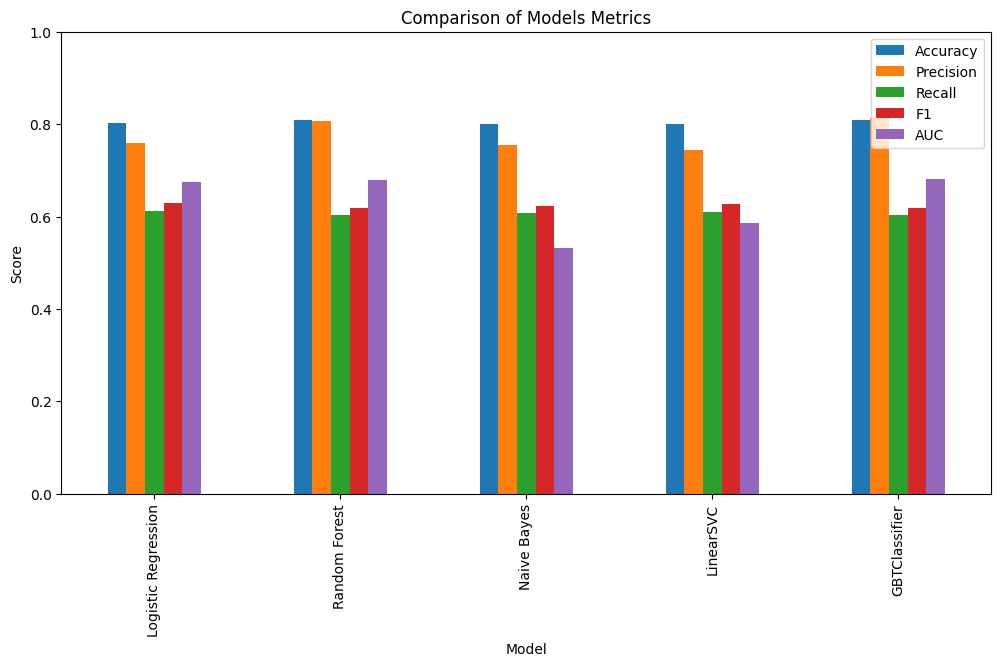

In [ ]:
    # -----------------------------
    # 5. Plot
    # -----------------------------
    import matplotlib.pyplot as plt

    df_results.plot(
        x="Model",
        y=["Accuracy","Precision","Recall","F1","AUC"],
        kind="bar",
        figsize=(12,6)
    )
    plt.title("Comparison of Models Metrics")
    plt.ylabel("Score")
    plt.ylim(0,1)
    plt.show()

VII.2 - ROC CURVE COMPARISON OF 5 MODELS

✅ Đã lưu ROC Curve so sánh 5 mô hình tại: /content/drive/MyDrive/modelss/roc_curve_comparison_5models.png


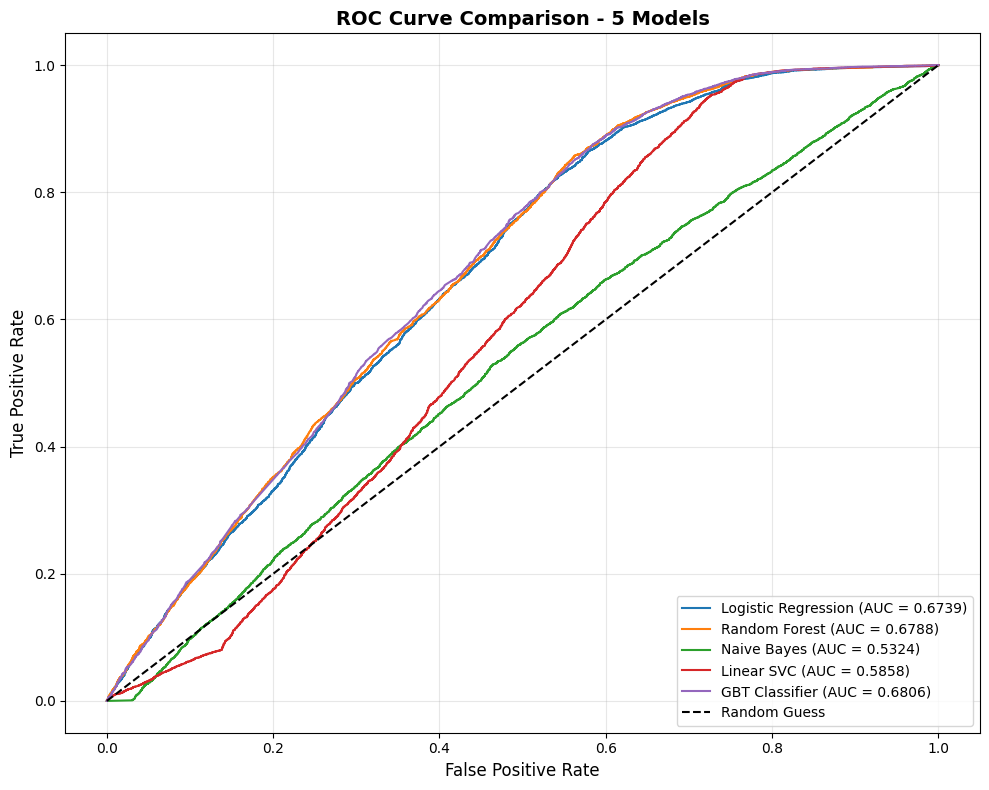

In [ ]:
# ================================================
# VII.2 - ROC CURVE SO SÁNH 5 MÔ HÌNH
# ================================================

import matplotlib.pyplot as plt
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from sklearn.metrics import roc_curve, auc
import pandas as pd

print("="*70)
print("VII.2 - ROC CURVE COMPARISON OF 5 MODELS")
print("="*70)

# Danh sách các model đã train
models = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "Naive Bayes": model_nb,
    "Linear SVC": model_svc,
    "GBT Classifier": model_gbt
}

plt.figure(figsize=(10, 8))

# Vẽ ROC cho từng model
for name, model in models.items():
    # Dự đoán trên test set
    predictions = model.transform(test_df)

    # Lấy rawPrediction và label
    y_true = predictions.select("label").toPandas()["label"]
    raw_pred = predictions.select("rawPrediction").toPandas()["rawPrediction"]

    # Lấy xác suất lớp positive (index 1)
    y_score = raw_pred.apply(lambda x: float(x[1]))

    # Tính fpr, tpr và AUC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    # Vẽ đường ROC
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

# Vẽ đường chéo ngẫu nhiên
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - 5 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF

# Khởi tạo các thành phần của Pipeline
tokenizer = Tokenizer(inputCol="review_comment_message", outputCol="tokens")
remover = StopWordsRemover(inputCol="tokens", outputCol="clean_tokens",
                           stopWords=StopWordsRemover.loadDefaultStopWords("portuguese"))
cv = CountVectorizer(inputCol="clean_tokens", outputCol="raw_features",
                     vocabSize=2000, minDF=5.0)
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")

# Đóng gói Pipeline
text_pipeline = Pipeline(stages=[tokenizer, remover, cv, idf])
